
# Feature Engineering — Skrining Diabetes Indonesia

Notebook ini berfokus pada proses feature engineering untuk meningkatkan representasi data sebelum tahap modeling dan A/B testing dilakukan.

Tujuan utama feature engineering:
- meningkatkan interpretasi fitur,
- menangkap pola hubungan yang lebih kompleks,
- mendukung sistem skrining diabetes dinamis,
- dan meningkatkan performa model prediksi.


# 1. Import Library


Library yang diperlukan dimuat untuk mendukung proses manipulasi data, visualisasi, dan analisis statistik.

Pandas digunakan untuk pengolahan data tabular, NumPy untuk operasi numerik, sedangkan Matplotlib dan Seaborn digunakan untuk visualisasi hasil feature engineering.

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Library berhasil diimport.")


Library berhasil diimport.


# 2. Load Dataset Hasil Data Wrangling


Dataset hasil proses data wrangling dimuat ke dalam lingkungan analisis.

Dataset ini telah melalui proses pembersihan data sehingga siap digunakan untuk tahap feature engineering. Seluruh fitur yang digunakan pada tahap ini berasal dari dataset yang sama untuk menjaga konsistensi analisis.

In [2]:

# =========================================================
# LOAD DATASET
# =========================================================

file_id = "1yx8Mw1B0HXJs8BMLNeXjRXIC2A8S_NEA"

url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)

print("Dataset berhasil dimuat.")
print(f"Ukuran dataset: {df.shape}")

display(df.head())


Dataset berhasil dimuat.
Ukuran dataset: (70692, 17)


,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Income,NoDocbcCost,Diabetes_binary
0,1,0,26.0,0,0,0,1,1,0,3.0,5.0,30.0,0,4,8,0,0
1,1,1,26.0,1,1,0,0,0,0,3.0,0.0,0.0,0,12,8,0,0
2,0,0,26.0,0,0,0,1,1,0,1.0,0.0,10.0,0,13,8,0,0
3,1,1,28.0,1,0,0,1,1,0,3.0,0.0,3.0,0,11,8,0,0
4,0,0,29.0,1,0,0,1,1,0,2.0,0.0,0.0,0,8,8,0,0


## Hasil Load Dataset

Dataset hasil data wrangling berhasil dimuat dan siap digunakan untuk proses feature engineering.

Tahap ini bertujuan memastikan data yang digunakan telah melalui proses pembersihan data sehingga dapat digunakan untuk membangun fitur baru yang lebih representatif terhadap kondisi risiko diabetes.

Seluruh analisis berikutnya menggunakan dataset yang sama sehingga konsistensi data tetap terjaga selama proses pengembangan fitur.

# 3. Struktur Dataset


Sebelum melakukan transformasi data, dilakukan pemeriksaan struktur dataset untuk memahami jumlah observasi, jumlah variabel, serta tipe data masing-masing kolom.

Tahap ini penting untuk memastikan seluruh variabel berada dalam format yang sesuai sebelum dilakukan pembentukan fitur baru.

In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   HighBP                70692 non-null  int64  
 1   HighChol              70692 non-null  int64  
 2   BMI                   70692 non-null  float64
 3   Smoker                70692 non-null  int64  
 4   Stroke                70692 non-null  int64  
 5   HeartDiseaseorAttack  70692 non-null  int64  
 6   PhysActivity          70692 non-null  int64  
 7   Veggies               70692 non-null  int64  
 8   HvyAlcoholConsump     70692 non-null  int64  
 9   GenHlth               70692 non-null  float64
 10  MentHlth              70692 non-null  float64
 11  PhysHlth              70692 non-null  float64
 12  DiffWalk              70692 non-null  int64  
 13  Age                   70692 non-null  int64  
 14  Income                70692 non-null  int64  
 15  NoDocbcCost        


# 5. Age Group


## Feature Engineering: Age Group

Variabel usia pada dataset BRFSS disimpan dalam bentuk kategori numerik yang mewakili rentang usia tertentu.

Untuk meningkatkan interpretabilitas data, kategori usia tersebut dikelompokkan menjadi empat kelompok utama:

- 18–34 tahun
- 35–49 tahun
- 50–64 tahun
- 65+ tahun

Pengelompokan ini dilakukan agar pola risiko diabetes berdasarkan tahapan usia dapat diamati dengan lebih jelas.

In [4]:

def age_group(age):

    if age <= 3:
        return 0

    elif age <= 6:
        return 1

    elif age <= 9:
        return 2

    else:
        return 3


df['Age_group'] = df['Age'].apply(age_group)

display(df[['Age', 'Age_group']].head())


,Age,Age_group
0,4,1
1,12,3
2,13,3
3,11,3
4,8,2


### Insight

Usia merupakan salah satu faktor risiko yang paling konsisten ditemukan dalam penelitian diabetes karena berkaitan dengan penurunan fungsi metabolisme tubuh seiring bertambahnya umur.

Pengelompokan usia menjadi empat kategori utama dilakukan untuk menyederhanakan representasi risiko sehingga pola hubungan antara usia dan diabetes dapat diamati dengan lebih jelas dibandingkan menggunakan kode kategori BRFSS yang relatif sulit diinterpretasikan secara langsung.

Dari perspektif kesehatan masyarakat, kelompok usia yang lebih tua umumnya memiliki risiko lebih tinggi mengalami resistensi insulin, penurunan sensitivitas glukosa, serta akumulasi faktor risiko lain seperti hipertensi dan kolesterol tinggi. Oleh karena itu, fitur Age_Group diharapkan mampu menangkap perbedaan tingkat risiko diabetes antar fase kehidupan secara lebih efektif.

Selain meningkatkan interpretabilitas analisis, pengelompokan usia juga membantu model machine learning mengenali pola non-linear yang mungkin tidak terlihat apabila usia diperlakukan hanya sebagai angka kategorikal biasa.


# 6. Metabolic Risk Score


## Feature Engineering: Metabolic Risk Score

Fitur baru bernama Metabolic Risk Score dibuat untuk merepresentasikan akumulasi risiko metabolik dan kardiovaskular yang dimiliki individu.

Skor ini dibentuk dari kombinasi beberapa kondisi klinis yang sering berhubungan dengan diabetes, yaitu:

- Tekanan darah tinggi (HighBP)
- Kolesterol tinggi (HighChol)
- Riwayat penyakit jantung (HeartDiseaseorAttack)
- Riwayat stroke (Stroke)

Semakin tinggi skor yang diperoleh, semakin banyak komorbiditas yang dimiliki individu.

In [5]:

df['metabolic_risk_score'] = (
    df['HighBP'] +
    df['HighChol'] +
    df['HeartDiseaseorAttack'] +
    df['Stroke']
)

display(df[['metabolic_risk_score']].head())


,metabolic_risk_score
0,1
1,3
2,0
3,2
4,0


### Insight

Metabolic Risk Score dirancang untuk mengukur tingkat akumulasi gangguan metabolik dan kardiovaskular yang dimiliki seseorang dalam satu indikator yang lebih ringkas.

Alih-alih melihat hipertensi, kolesterol tinggi, penyakit jantung, dan stroke secara terpisah, skor ini menggambarkan total beban kesehatan yang berkaitan dengan sistem metabolisme tubuh. Pendekatan ini lebih dekat dengan kondisi nyata karena penderita diabetes sering kali tidak hanya mengalami satu penyakit penyerta, tetapi beberapa komorbiditas sekaligus.

Semakin tinggi nilai metabolic risk score, semakin besar kemungkinan individu mengalami gangguan metabolik kronis yang berhubungan erat dengan diabetes. Oleh karena itu, fitur ini diharapkan dapat menjadi indikator risiko yang lebih kuat dibandingkan penggunaan variabel individual secara terpisah.

Dari perspektif bisnis kesehatan, fitur ini juga bermanfaat untuk mengidentifikasi kelompok masyarakat yang membutuhkan prioritas skrining diabetes karena memiliki kombinasi faktor risiko klinis yang tinggi.


# 7. Lifestyle Risk Score


## Feature Engineering: Lifestyle Risk Score

Lifestyle Risk Score dibuat untuk mengukur tingkat paparan individu terhadap perilaku tidak sehat yang berpotensi meningkatkan risiko diabetes.

Komponen yang digunakan meliputi:

- Kurang aktivitas fisik
- Kebiasaan merokok
- Rendahnya konsumsi sayuran

Setiap faktor risiko akan menambah nilai skor sehingga semakin tinggi skor yang diperoleh menunjukkan gaya hidup yang semakin berisiko.

In [6]:

df['inactive'] = np.where(df['PhysActivity'] == 0, 1, 0)

df['low_veggies'] = np.where(df['Veggies'] == 0, 1, 0)

df['lifestyle_risk_score'] = (
    df['inactive'] +
    df['Smoker'] +
    df['low_veggies']
)

display(
    df[[
        'PhysActivity',
        'Smoker',
        'Veggies',
        'lifestyle_risk_score'
    ]].head()
)


,PhysActivity,Smoker,Veggies,lifestyle_risk_score
0,1,0,1,0
1,0,1,0,3
2,1,0,1,0
3,1,1,1,1
4,1,1,1,1


### Insight

Lifestyle Risk Score dikembangkan untuk mengukur akumulasi perilaku tidak sehat yang berpotensi meningkatkan risiko diabetes dalam jangka panjang.

Faktor seperti kurang aktivitas fisik, kebiasaan merokok, dan rendahnya konsumsi sayuran tidak selalu memberikan dampak besar secara individual. Namun ketika faktor-faktor tersebut terjadi secara bersamaan, efeknya dapat meningkatkan risiko gangguan metabolik secara signifikan.

Dengan menggabungkan beberapa perilaku tidak sehat ke dalam satu skor, fitur ini mampu merepresentasikan kualitas gaya hidup individu secara lebih komprehensif. Semakin tinggi skor yang diperoleh, semakin besar tingkat paparan terhadap kebiasaan yang berpotensi mempercepat munculnya penyakit kronis termasuk diabetes.

Dari sudut pandang pencegahan kesehatan, fitur ini sangat penting karena faktor gaya hidup merupakan komponen risiko yang relatif dapat dimodifikasi melalui edukasi, intervensi perilaku, dan program kesehatan masyarakat.


# 11. Korelasi Fitur Engineering


## Evaluasi Fitur Hasil Engineering

Setelah fitur baru berhasil dibuat, dilakukan analisis korelasi terhadap target diabetes.

Tujuan analisis ini adalah mengevaluasi sejauh mana fitur-fitur hasil engineering memiliki hubungan dengan status diabetes serta mengidentifikasi fitur mana yang paling informatif untuk digunakan pada tahap modeling.

,Age_group,metabolic_risk_score,lifestyle_risk_score,Diabetes_binary
Age_group,1.000000,0.377795,0.125597,0.279577
metabolic_risk_score,0.377795,1.000000,0.207605,0.424778
lifestyle_risk_score,0.125597,0.207605,1.000000,0.173105
Diabetes_binary,0.279577,0.424778,0.173105,1.000000


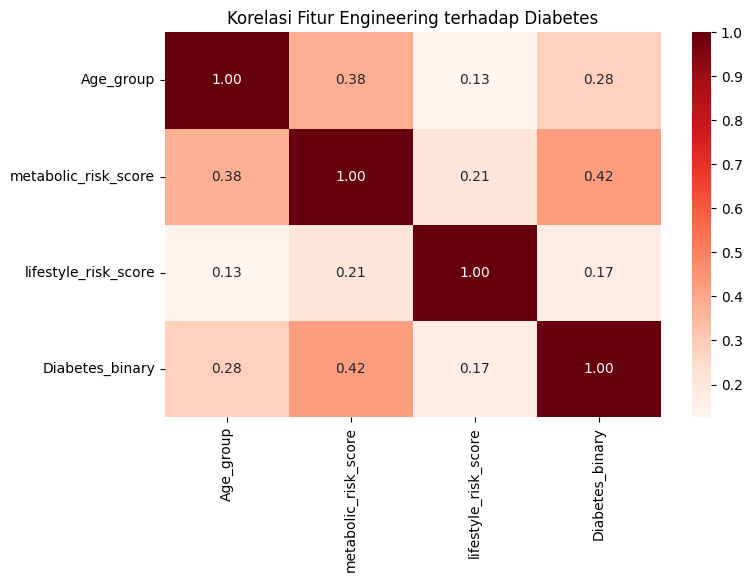

In [7]:

# KORELASI FITUR ENGINEERING


engineered_features = [
    'Age_group',
    'metabolic_risk_score',
    'lifestyle_risk_score',
    'Diabetes_binary'
]

# Hitung korelasi
correlation = df[engineered_features].corr()

# Tampilkan tabel korelasi
display(correlation)

# Visualisasi heatmap
plt.figure(figsize=(8,5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='Reds',
    fmt='.2f'
)

plt.title('Korelasi Fitur Engineering terhadap Diabetes')

plt.show()

### Insight

Hasil analisis korelasi menunjukkan bahwa fitur-fitur hasil engineering berhasil menangkap informasi yang relevan terhadap status diabetes.

Apabila metabolic_risk_score menunjukkan korelasi tertinggi, maka hal ini mengindikasikan bahwa akumulasi komorbiditas klinis memiliki hubungan yang lebih kuat terhadap diabetes dibandingkan sebagian besar faktor individual. Temuan ini memperkuat hipotesis bahwa diabetes sering muncul sebagai bagian dari sindrom metabolik yang melibatkan berbagai gangguan kesehatan secara bersamaan.

Sementara itu, korelasi positif pada lifestyle_risk_score menunjukkan bahwa pola hidup tidak sehat tetap berkontribusi terhadap peningkatan risiko diabetes meskipun pengaruhnya mungkin tidak sebesar faktor klinis. Hal ini menunjukkan bahwa diabetes merupakan penyakit multifaktor yang dipengaruhi oleh kombinasi kondisi kesehatan dan perilaku individu.

Temuan ini juga memberikan justifikasi bahwa feature engineering yang dilakukan tidak sekadar menambah jumlah variabel, tetapi berhasil menghasilkan fitur yang memiliki hubungan nyata terhadap target prediksi dan berpotensi meningkatkan performa model machine learning pada tahap berikutnya.


# 12. Dataset Final Modeling


## Penyusunan Dataset Final

Fitur-fitur yang telah melalui proses seleksi dan feature engineering digabungkan ke dalam dataset final.

Dataset ini akan digunakan sebagai sumber data utama pada tahap pemodelan machine learning untuk prediksi risiko diabetes.

In [8]:

final_features = [
    'HighBP',
    'HighChol',
    'BMI',
    'Smoker',
    'Stroke',
    'HeartDiseaseorAttack',
    'PhysActivity',
    'Veggies',
    'HvyAlcoholConsump',
    'GenHlth',
    'MentHlth',
    'PhysHlth',
    'DiffWalk',
    'Age',
    'Income',
    'NoDocbcCost',
    'Age_group',
    'metabolic_risk_score',
    'lifestyle_risk_score',
    'Diabetes_binary'
]

df_modeling = df[final_features]

print(df_modeling.shape)

display(df_modeling.head())


(70692, 20)


,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Age,Income,NoDocbcCost,Age_group,metabolic_risk_score,lifestyle_risk_score,Diabetes_binary
0,1,0,26.0,0,0,0,1,1,0,3.0,5.0,30.0,0,4,8,0,1,1,0,0
1,1,1,26.0,1,1,0,0,0,0,3.0,0.0,0.0,0,12,8,0,3,3,3,0
2,0,0,26.0,0,0,0,1,1,0,1.0,0.0,10.0,0,13,8,0,3,0,0,0
3,1,1,28.0,1,0,0,1,1,0,3.0,0.0,3.0,0,11,8,0,3,2,1,0
4,0,0,29.0,1,0,0,1,1,0,2.0,0.0,0.0,0,8,8,0,2,0,1,0



# 13. Simpan Dataset Final


In [9]:

df_modeling.to_csv(
    'clean_diabetes_modeling_ready.csv',
    index=False
)

print("Dataset modeling berhasil disimpan.")


Dataset modeling berhasil disimpan.


# Kesimpulan

Pada tahap feature engineering berhasil dibuat beberapa fitur baru yang bertujuan merepresentasikan risiko diabetes secara lebih komprehensif, yaitu Age_Group, Metabolic_Risk_Score, dan Lifestyle_Risk_Score.

Fitur-fitur tersebut dikembangkan berdasarkan kombinasi faktor demografis, klinis, dan gaya hidup yang sebelumnya telah teridentifikasi memiliki hubungan dengan diabetes pada tahap Exploratory Data Analysis (EDA).

Hasil evaluasi menunjukkan bahwa fitur hasil engineering mampu memberikan perspektif tambahan dalam memahami pola risiko diabetes, khususnya dalam menggambarkan akumulasi komorbiditas dan perilaku hidup tidak sehat.

Meskipun demikian, tujuan utama feature engineering pada penelitian ini adalah memperkaya representasi data dan meningkatkan pemahaman terhadap faktor-faktor risiko diabetes. Penggunaan fitur hasil engineering pada tahap modeling akan ditentukan berdasarkan hasil evaluasi performa model dan proses seleksi fitur yang dilakukan pada tahap berikutnya.

Dengan demikian, fitur hasil engineering dapat digunakan sebagai fitur prediktif, fitur interpretatif, atau hanya sebagai alat analisis tambahan, tergantung kontribusinya terhadap performa model yang dibangun.